# Financial Econometrics I - Project
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)

**Note**: RV is provided as Realized Volatility. As such, all models are estimated on that scale, unless specified otherwise.

**AI tool usage**: 

**Data used**: `Asset 12`

---

## Setup

In [1]:
library(xts)
library(forecast) 
library(rugarch)
library(lmtest)
library(sandwich)

options(repr.plot.width = 12, repr.plot.height = 7)

Warning message:
"package 'xts' was built under R version 4.5.2"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: parallel



In [26]:
#library(zoo) ####### not used
#library(ggplot2) ###### not used
#library(fGarch) ###########delete
#library(tseries) ###### not used

NOTE: Packages 'fBasics', 'timeDate', and 'timeSeries' are no longer
attached to the search() path when 'fGarch' is attached.

If needed attach them yourself in your R script by e.g.,
        require("timeSeries")



In [3]:
#Loading data
load("data_project/12.RData")

dates <- as.Date(index(adp))
df <- data.frame(date = dates, coredata(adp)) #xts to df for regressions
n <- nrow(df)

str(df)
head(df, 3)
tail(df, 1)
colSums(is.na(df))

'data.frame':	1500 obs. of  7 variables:
 $ date: Date, format: "2010-01-05" "2010-01-06" ...
 $ ret : num  -0.02065 0.00351 -0.01578 0.00686 0 ...
 $ RV  : num  0.00735 0.00726 0.00825 0.01071 0.00819 ...
 $ RV_p: num  0.00541 0.00527 0.00638 0.00832 0.00587 ...
 $ RV_n: num  0.00498 0.00499 0.00522 0.00674 0.00572 ...
 $ RS  : num  0.14174 0.37146 0.63841 0.82536 -0.00218 ...
 $ RK  : num  4.47 4.65 5.18 8.59 3.6 ...


,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2010-01-05,-0.02065318,0.007350539,0.005405043,0.004981559,0.1417402,4.466892
2,2010-01-06,0.00351129,0.007256418,0.005266342,0.004992118,0.3714606,4.651872
3,2010-01-07,-0.01577893,0.008245743,0.006380770,0.005222840,0.6384128,5.184831


,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1500,2016-01-22,0.02683273,0.01078354,0.008042433,0.007183591,0.3585356,3.632521


date  ret   RV RV_p RV_n   RS   RK 
   0    0    0    0    0    0    0

---
# 1. Data Description

The dataset contains 1,500 daily observations of Asset 12 over time period of January 5, 2010 through January 22, 2016. Six variables are included: returns (ret), realized volatility (RV), positive realized semi-volatility (RV_p) and negative realized semi-volatility (RV_n), realized skewness (RS) and realized kurtosis (RK). No data is missing.

## Descriptive Statistics

In [4]:
vars <- c("ret", "RV", "RV_p", "RV_n", "RS", "RK")

#Functions for sample skewness and excess kurtosis
skew <- function(x) {
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  
  n / ((n - 1) * (n - 2)) * sum(((x - x_bar) / s)^3) #bias corrected skew
}

kurt <- function(x) {
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  
  term1 <- (n * (n + 1)) / ((n - 1) * (n - 2) * (n - 3)) #bias correction factor
  term2 <- 3 * (n - 1)^2 / ((n - 2) * (n - 3)) #bias corrected version of -3
  
  term1 * sum(((x - x_bar) / s)^4) - term2 #excess kurtosis
}

desc <- data.frame(
  variable = vars,
  min = sapply(vars, function(v) min(df[[v]])),
  mean = sapply(vars, function(v) mean(df[[v]])),
  median = sapply(vars, function(v) median(df[[v]])),
  max = sapply(vars, function(v) max(df[[v]])),
  sd = sapply(vars, function(v) sd(df[[v]])),
  skewness = sapply(vars, function(v) skew(df[[v]])),
  ex_kurt = sapply(vars, function(v) kurt(df[[v]])),
  n = sapply(vars, function(v) sum(!is.na(df[[v]])))
)
round(desc[, -1], 5)

,min,mean,median,max,sd,skewness,ex_kurt,n
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ret,-0.13124,0.00052,0.00072,0.06243,0.01258,-0.93020,11.43632,1500
RV,0.00333,0.00888,0.00807,0.09567,0.00434,8.34182,138.23081,1500
RV_p,0.00170,0.00624,0.00572,0.09320,0.00339,12.61247,295.39560,1500
RV_n,0.00168,0.00618,0.00554,0.05952,0.00300,5.37825,72.71287,1500
RS,-8.11384,0.01118,0.01638,6.62202,1.12760,-0.38673,5.01832,1500
RK,2.15327,6.11569,4.61776,69.69763,4.90279,4.87688,38.27971,1500


The **returns** are close to zero mean and are negatively skewed with positive excess kurtosis. This is common when describing the characteristics of financial returns. **Realized Volatility (RV)** appears to be right skewed; the mean is greater than the median`, and has some larger spikes within the dataset reflecting volatility clustering.` The two realized semi-variabilities **(RV_p & RV_n)** have nearly identical means in this example, although they differ substantially in higher moments. `although it may be an anomaly of this particular asset`. **Realized Skewness (RS)** is centered close to zero, however, it can range anywhere from approximately (-8) to (+6) - extreme skewness is more severe on the negative side. `Therefore, there will occasionally be days where the intraday asymmetry will be significantly different from average.`  **Realized Kurtosis (RK)** is generally well above 3 and is also highly right skewed. `Many days' returns exhibit more severe tailed distributions than those described by a standard normal distribution.` Fat-tailed intraday distributions appear to be the norm. Some days have extreme tail behaviour reaching as high as 69.7.

## Time Series Plots

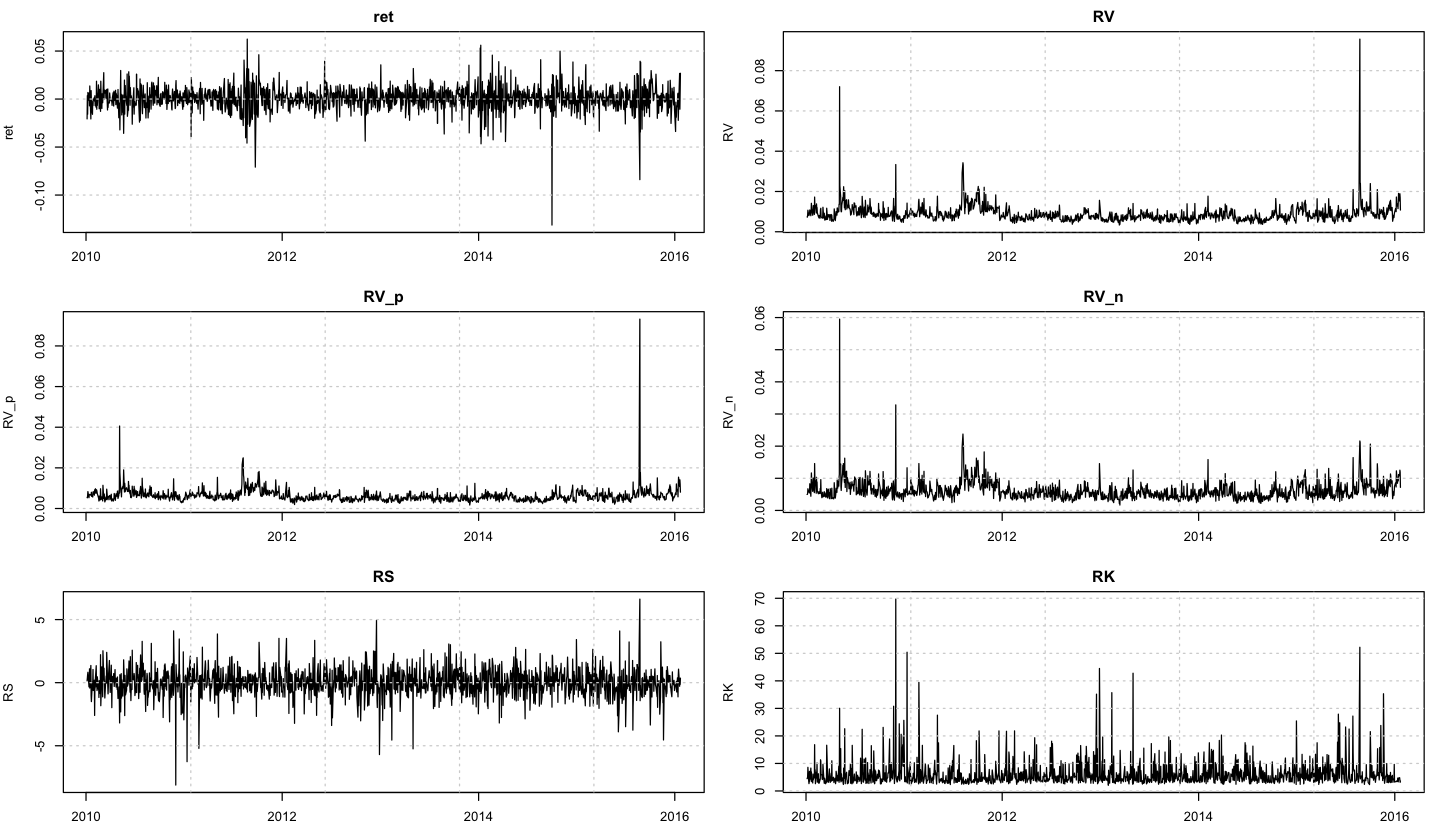

In [5]:
par(mfrow = c(3, 2), mar = c(3, 4, 2, 1))
for (v in vars) {
  plot(df$date, df[[v]], type = "l", main = v, xlab = "", ylab = v)
  grid()
}

The evidence from RV clearly demonstrates that the returns exhibit **"volatility clustering"** (i.e., periods of calm markets and those of turbulence) and that periods of high volatility in the returns typically remain for a number of weeks. Visually, the returns appear to be `roughly` stationary; however, they do occasionally experience severe negative shocks. **RV** exhibits 2-4 sharp temporary spikes, which return to base levels rather quickly. The behaviour of both **RV_p and RV_n** appears very similar. Nevertheless, it is evident that the most negative and most positive volatility spikes, do not occur at the same time. `yet are never identical.` **RS** does not portray evident clusters and fluctuates around 0. `occasionally has an extreme spikes when the stock's price or volume exhibits unusual behavior throughout the trading day.` **RK**: there seems to be some correlation between RK and RV spikes. RK, which appears to be consistently above 3, exhibits numerous spikes along the sample, with the most extreme one falling within a positive net return day, as it can be seen below.

In [6]:
df[which.max(df$RK), ]

,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
228,2010-12-01,0.0142171,0.03337935,0.006029963,0.03283017,-8.113845,69.69763


## ACF Plots

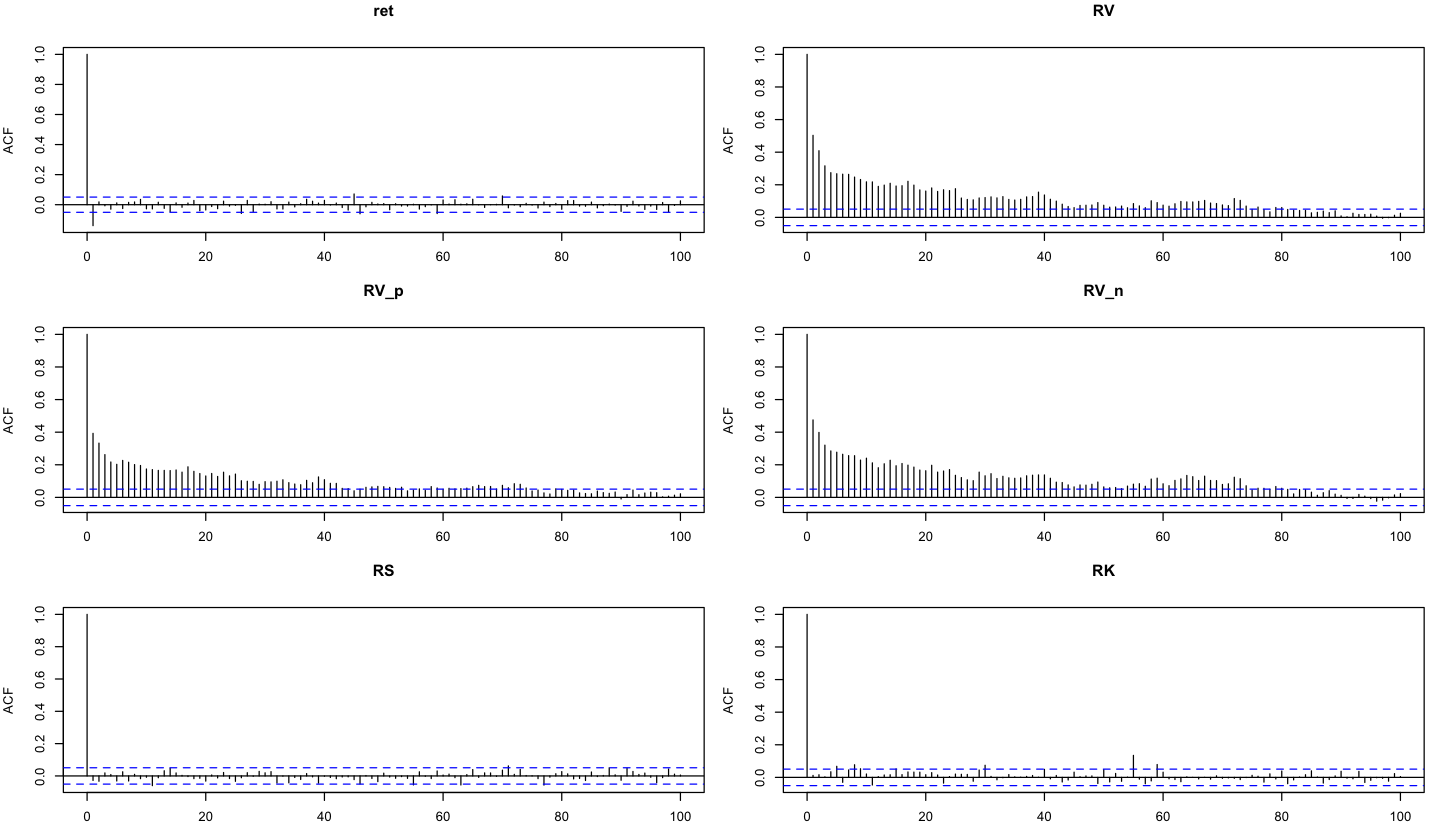

In [7]:
par(mfrow = c(3, 2), mar = c(3, 4, 3, 1))
for (v in vars) {
  acf(df[[v]], lag.max = 100, main = paste(v))
}

**Returns** demonstrate almost no serial correlation at any lag (mostly lag 1), which is consistent with weak form market efficiency. **RV, RV_p, and RV_n** demonstrate a strong autocorrelation that is relatively slow to decay. This suggests the presence of persistent volatility dynamics that motivates the use of the HAR (Heterogeneous Autoregressive) model. **RS** is close to a white noise - `therefore it displays characteristics typical of such as well as` nearly no autocorrelation. **RK** `has some level of serial correlation at shorter lags; however, this autocorrelation dissipates much quicker than the autocorrelations seen in the volatility measures.` does not seem to portray systematic autocorrelation, with several lags crossing the significance level rather arbitrarily. 

## Histograms & Density

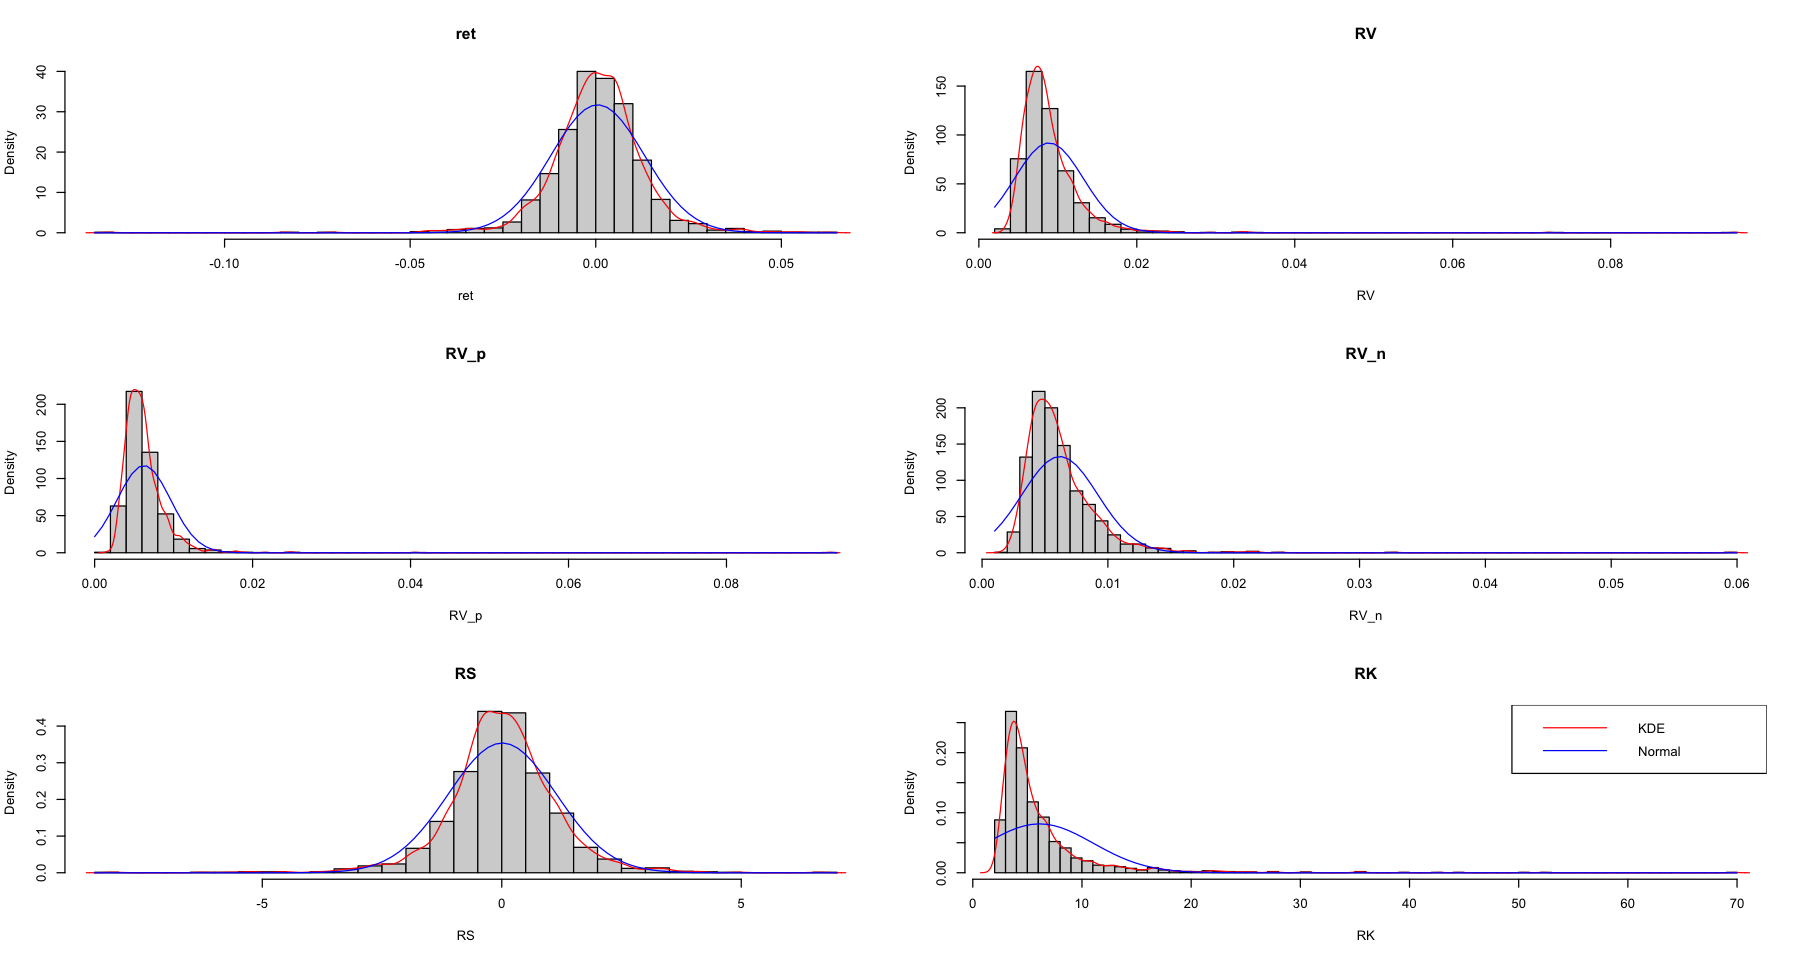

In [8]:
options(repr.plot.height = 8, repr.plot.width = 15)
par(mfrow = c(3, 2))

for (v in vars) {
  hist(df[[v]], breaks = 50, main = v, xlab = v, freq = FALSE)
  lines(density(df[[v]]), col = "red")
  curve(dnorm(x, mean = mean(df[[v]]), sd = sd(df[[v]])),
    add = TRUE, col = "blue")
}

legend("topright", legend = c("KDE", "Normal"),
  col = c("red", "blue"), lty = 1)

The **returns** appear to be rather close to normally distributed; however, they have "fatter tails" than a true normal distribution (which corresponds to the excess kurtosis reported in the descriptive statistics). All **three RV metrics** are skewed toward the right with an extended tail - i.e., most of the time, intraday volatilities are relatively low, but from time-to-time, volatility spikes significantly. **RS** appears to be approximately symmetrical around zero but it is more heavily tailed than a normal ( substantial intra-day skewness occurs at times). **RK** is centered around 3-5, but it also has a significant amount of mass in its `upper-`right tail`, with some large outliers present for days when both intra-day returns are characterized by large amounts of heavy-tail behavior?` with very large outliers. Normal distribution is a poor fit overall.

# 2. In-Sample Fit

We estimate **six volatility models** on all of our sample data. Our HAR family models have $RV_t$ (Realized Volatility) as their dependent variable. `Our GARCH family models measure the conditional volatility of stock returns ($h_t$) and map that back onto the RV scale via a measurement equation.` Our GARCH family models measure the Conditional Variance ($h_t$) of stock returns. Their $\sigma_t=sqrt(h_t)$ can therefore be directly compared against $RV_t$.

## Constructing Regressors

The HAR family has three measures of how long past volatilities continue in some form of past behavior. Those are **daily**, **weekly** (a 5-day average) and **monthly** (a 22-day average). All regressors are lagged by one day to ensure we use only information available at time $t-1$.

In [9]:
#Extracting the variables used in the models
RV <- df$RV
ret <- df$ret
RV_p <- df$RV_p
RV_n <- df$RV_n
RS <- df$RS
RK <- df$RK

#Function for trailing moving averages
ma <- function(x, k) {
  as.numeric(stats::filter(x, rep(1 / k, k), sides = 1))
}

#Weekly & monthly averages
RV_w <- ma(RV, 5)
RV_m <- ma(RV, 22)

RVp_w <- ma(RV_p, 5)
RVp_m <- ma(RV_p, 22)

RVn_w <- ma(RV_n, 5)
RVn_m <- ma(RV_n, 22)

RS_w <- ma(RS, 5)
RS_m <- ma(RS, 22)

RK_w <- ma(RK, 5)
RK_m <- ma(RK, 22)


#Starting from observation 23 because the 22-day average needs enough past data
s <- 23

#Regression ready dataset
model_df <- data.frame(
  date = df$date[s:n],
  RV = RV[s:n],
  
  RV_lag1 = RV[(s - 1):(n - 1)], #RV at t, regressors at t-1
  RV_w = RV_w[(s - 1):(n - 1)],
  RV_m = RV_m[(s - 1):(n - 1)],
  
  RVp_lag1 = RV_p[(s - 1):(n - 1)],
  RVn_lag1 = RV_n[(s - 1):(n - 1)],
  RVp_w = RVp_w[(s - 1):(n - 1)],
  RVn_w = RVn_w[(s - 1):(n - 1)],
  RVp_m = RVp_m[(s - 1):(n - 1)],
  RVn_m = RVn_m[(s - 1):(n - 1)],
  
  RS_lag1 = RS[(s - 1):(n - 1)],
  RS_w = RS_w[(s - 1):(n - 1)],
  RS_m = RS_m[(s - 1):(n - 1)],
  
  RK_lag1 = RK[(s - 1):(n - 1)],
  RK_w = RK_w[(s - 1):(n - 1)],
  RK_m = RK_m[(s - 1):(n - 1)],
  
  ret_lag1 = ret[(s - 1):(n - 1)])

model_df <- na.omit(model_df)

nrow(model_df)

[1] 1478

## Model 1: AR(1)-RV

$$RV_t = \beta_0 + \beta_1\, RV_{t-1} + \varepsilon_t$$

In [10]:
m1 <- lm(RV ~ RV_lag1, data = model_df)

summary(m1)


Call:
lm(formula = RV ~ RV_lag1, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.028461 -0.001651 -0.000438  0.000946  0.081357 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.004398   0.000222   19.81   <2e-16 ***
RV_lag1     0.503519   0.022485   22.39   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003767 on 1476 degrees of freedom
Multiple R-squared:  0.2536,	Adjusted R-squared:  0.2531 
F-statistic: 501.5 on 1 and 1476 DF,  p-value: < 2.2e-16


The **AR(1) coefficient** on the lagged RV is nearly **0.50** and highly significant. Thus, we can see a large/moderate amount of day-to-day persistence in volatility. We find an adjusted R² of approximately **0.25** - a quarter of the variance in the current day's volatility is explained by the previous day's volatility. This is the simplest baseline.

## Model 2: HAR-RV

$$RV_t = \beta_0 + \beta_d\, RV_{t-1} + \beta_w\, RV_{t-1}^{(w)} + \beta_m\, RV_{t-1}^{(m)} + \varepsilon_t$$

In [11]:
m2 <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df)

summary(m2)


Call:
lm(formula = RV ~ RV_lag1 + RV_w + RV_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018237 -0.001543 -0.000375  0.000985  0.082325 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0016237  0.0003591   4.521 6.63e-06 ***
RV_lag1     0.3226509  0.0299412  10.776  < 2e-16 ***
RV_w        0.1932316  0.0529429   3.650 0.000272 ***
RV_m        0.3015702  0.0582013   5.181 2.51e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003641 on 1474 degrees of freedom
Multiple R-squared:  0.3036,	Adjusted R-squared:  0.3022 
F-statistic: 214.2 on 3 and 1474 DF,  p-value: < 2.2e-16


Because in HAR models the rolling weekly ($RV_t^{(w)}$) and monthly ($RV_t^{(m)}$) averages overlap over consecutive periods, this makes the OLS residuals exhibit serial correlation. As such, the standard errors are biased. We correct for this using Newey West standard errors at lag 22 (the largest lag in the model).

In [12]:
NW2 <- NeweyWest(m2, lag=22)
coeftest(m2, vcov=NW2)



t test of coefficients:

              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.00162372 0.00034949  4.6459 3.687e-06 ***
RV_lag1     0.32265093 0.04945564  6.5240 9.383e-11 ***
RV_w        0.19323161 0.04945005  3.9076 9.744e-05 ***
RV_m        0.30157015 0.05686121  5.3036 1.308e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


We find all of these components of volatility persistence to be **statistically significant**. The daily lagged term provides the largest contribution to volatility persistence (approximately 0.32). It represents a measure of short-term persistence in volatility. Next, we find the weekly average term contributing a smaller portion of total variability in volatility (around 0.19). Therefore, it provides evidence of medium-term volatility clustering. Lastly, we also indentify the monthly average term to be statistically significant `and provided another, larger portion of total variability in volatility` with a coefficient of approximately 0.30. Finally, we can see a `substantial` meaningful increase in the adjusted R² to around 0.30, which indicates volatility persistence occurring on multiple time scales simultaneously.

## Model 3: HAR-RS (Realized Semivariances)

We `split RV into` use positive (RV_p) and negative (RV_n) semi-volatility for each of our three time horizons based on Patton & Sheppard (2015). In our data, RV_p and RV_n are semi-volatilities (not variances) – they satisfy $RV_p^2 + RV_n^2 = RV^2$ rather than summing to RV directly. This segmentation allows the predictive power of upside versus downside movements to be different for future volatility. 

$$RV_t = \beta_0 + \beta_d^{+} RV_{p,t-1} + \beta_d^{-} RV_{n,t-1} + \beta_w^{+} RV_{p,t-1}^{(w)} + \beta_w^{-} RV_{n,t-1}^{(w)} + \beta_m^{+} RV_{p,t-1}^{(m)} + \beta_m^{-} RV_{n,t-1}^{(m)} + \varepsilon_t$$

In [13]:
m3 <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df)

summary(m3)


Call:
lm(formula = RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
    RVn_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015436 -0.001529 -0.000345  0.000964  0.082062 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0014300  0.0003587   3.986 7.04e-05 ***
RVp_lag1    0.1819176  0.0410720   4.429 1.02e-05 ***
RVn_lag1    0.3605367  0.0489478   7.366 2.92e-13 ***
RVp_w       0.0783204  0.1028962   0.761   0.4467    
RVn_w       0.1724096  0.1150019   1.499   0.1340    
RVp_m       0.0193103  0.2012518   0.096   0.9236    
RVn_m       0.3905262  0.2129960   1.833   0.0669 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003602 on 1471 degrees of freedom
Multiple R-squared:  0.3197,	Adjusted R-squared:  0.317 
F-statistic: 115.2 on 6 and 1471 DF,  p-value: < 2.2e-16


In [14]:
NW3 <- NeweyWest(m3, lag=22)
coeftest(m3, vcov=NW3)


t test of coefficients:

              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.00143001 0.00027549  5.1908 2.387e-07 ***
RVp_lag1    0.18191759 0.04247937  4.2825 1.968e-05 ***
RVn_lag1    0.36053667 0.09115347  3.9553 8.009e-05 ***
RVp_w       0.07832040 0.09287277  0.8433   0.39919    
RVn_w       0.17240962 0.10713041  1.6093   0.10776    
RVp_m       0.01931026 0.13857214  0.1394   0.88919    
RVn_m       0.39052622 0.16106421  2.4247   0.01544 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


The daily negative semi-volatility coefficient of around 0.36 is approximately double that of its positive counterpart (0.18), each of which is statistically significant. Both results align with a **leverage-type asymmetry**; large down-side movements generally forecast larger subsequent volatilities relative to corresponding up-side movements. At longer horizons, weekly and monthly terms, `various coefficients are in agreement as far as the signs, however most do not reach statistical significance` the coefficients keep the same sign pattern (negative semivariances having a higher coefficient), although only the monthly negative semivariance reaches statistical significance at the 5% level (the only change in significance after implementation of NW se). Adjusted $R^2$ is around 0.32 and thus shows an improvement on the standard HAR. As such, separation of positive and negative variation adds predictive power. 

## Model 4: HAR-Rskew-Rkurt

We augment the HAR-RS model with realized skewness and realized kurtosis at daily, weekly, and monthly horizons:

$$RV_t = \beta_0 + \beta_d^{+} RV_{p,t-1} + \beta_d^{-} RV_{n,t-1} + \beta_w^{+} RV_{p,t-1}^{(w)} + \beta_w^{-} RV_{n,t-1}^{(w)} + \beta_m^{+} RV_{p,t-1}^{(m)} + \beta_m^{-} RV_{n,t-1}^{(m)}$$
$$+ \gamma_d RS_{t-1} + \gamma_w RS_{t-1}^{(w)} + \gamma_m RS_{t-1}^{(m)} + \delta_d RK_{t-1} + \delta_w RK_{t-1}^{(w)} + \delta_m RK_{t-1}^{(m)} + \varepsilon_t$$

In [15]:
m4 <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m +
           RS_lag1 + RS_w + RS_m +
           RK_lag1 + RK_w + RK_m, data = model_df)

summary(m4)


Call:
lm(formula = RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
    RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018383 -0.001526 -0.000372  0.000931  0.081691 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.260e-03  6.304e-04   3.584 0.000349 ***
RVp_lag1     1.225e-01  5.777e-02   2.121 0.034052 *  
RVn_lag1     5.140e-01  7.168e-02   7.170 1.19e-12 ***
RVp_w        1.099e-02  1.575e-01   0.070 0.944356    
RVn_w        2.447e-01  1.755e-01   1.394 0.163426    
RVp_m       -1.466e-01  2.937e-01  -0.499 0.617916    
RVn_m        4.678e-01  3.089e-01   1.514 0.130123    
RS_lag1      3.031e-04  1.437e-04   2.109 0.035155 *  
RS_w         2.208e-04  3.808e-04   0.580 0.562158    
RS_m         3.883e-04  7.239e-04   0.536 0.591701    
RK_lag1     -6.980e-05  2.385e-05  -2.926 0.003483 ** 
RK_w        -1.193e-04  5.897e-05  -2.022 0.043319 *  
RK_m    

In [16]:
NW4 <- NeweyWest(m4, lag=22)
coeftest(m4, vcov=NW4)


t test of coefficients:

               Estimate  Std. Error t value Pr(>|t|)   
(Intercept)  2.2596e-03  8.3083e-04  2.7197 0.006611 **
RVp_lag1     1.2255e-01  8.5732e-02  1.4294 0.153099   
RVn_lag1     5.1395e-01  1.9351e-01  2.6559 0.007996 **
RVp_w        1.0992e-02  1.3677e-01  0.0804 0.935952   
RVn_w        2.4469e-01  1.4616e-01  1.6741 0.094331 . 
RVp_m       -1.4655e-01  1.6850e-01 -0.8697 0.384580   
RVn_m        4.6780e-01  1.8774e-01  2.4918 0.012820 * 
RS_lag1      3.0305e-04  3.3111e-04  0.9153 0.360199   
RS_w         2.2080e-04  3.5217e-04  0.6270 0.530774   
RS_m         3.8834e-04  4.5866e-04  0.8467 0.397305   
RK_lag1     -6.9799e-05  3.7857e-05 -1.8437 0.065422 . 
RK_w        -1.1927e-04  6.9040e-05 -1.7275 0.084295 . 
RK_m         4.3984e-05  1.0851e-04  0.4053 0.685287   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In Model 4, NW se lead to the statistical significance of several coefficients to change.

Semivariance coefficients follow a similar pattern as found in HAR-RS, although the positive RV at lag 1 is no longer significant. Montly negative RV is now significant at 5%.

Regarding higher moments `semivariance`, the daily realized skewness coefficient is positive although no longer significant after NW - `given that there are more extreme (positively) skewed intraday returns today predict higher realized volatility tomorrow`. Weekly and monthly RS coefficients are insignificant. Daily and weekly realized kurtosis coefficients are negative and marginally significant at 10%. `This may seem unexpected at first, as we would expect fatter tails today to predict more volatility tomorrow but likely reflects mean-reversion, but once we control for the level of volatility through the semivariances, extremely heavy tailed days are likely to be followed by much calmer days. The monthly RK coefficient is insignificant.` Adjusted R² values reach around 0.33, the highest R² value of all the HAR type models (slight improvement over HAR_RS). This indicates that skewness and kurtosis provide some limited additional information on predicting future volatility, above and beyond the semivariance breakdown. At least after correcting for autocorellation in standard errors.

## `Model 5: Realized GARCH (Approximation)`

The Realized GARCH of Hansen, Huang and Shek (2012) is a joint model. It estimates three equations in total; a return equation, a variance equation that utilizes realized volatility as a feedback mechanism for variance, and an estimation equation (measurement equation) to estimate the parameters of the first two. Since we can't run this entire model here (the rugarch package is needed), we create a **two-stage approximation** of the original model;

1. Fit a standard GARCH(1,1) on returns to get the conditional variance $h_t$.
2. Regress: $RV_t = \xi_0 + \xi_1\, h_t + u_t$.

This isn't a true Realized GARCH. RV does not get fed back into the variance equation. We're estimating $h_t$ using only returns data and then estimating how these values map to RV using a second stage OLS estimation. Therefore the results need to be viewed with this in mind

In [29]:
#Fitting GARCH(1,1) on returns, same sample as HAR models
#ret_model <- df$ret[s:n][1:nrow(model_df)]
#garch11 <- garchFit(~ garch(1,1), data = ret_model, trace = FALSE)
#summary(garch11)

In [30]:
#Measurement equation

#h_t <- garch11@h.t
#m5_meas <- lm(model_df$RV ~ h_t)
#summary(m5_meas)

The estimates for the GARCH (1, 1) are: $\alpha_1 = ~0.35$  & $\beta_1 = ~0.43$. Thus, there is persistence in the system at about 0.78. It's less than 1 which indicates that both the variance and the returns process are stationary and mean-reverting.

We see in our results that the variance does link to returns (RV), however, it also appears to be very weak as indicated by the low adjusted $R^2$ of approximately 0.04. That's not surprising since $h_t$ is estimated purely from returns. Thus, if we can estimate a Realized GARCH model where RV is fed back into the variance equation then it's likely to perform better, but we cannot test this here.

## `Model 6: ARMA(1,1)-GARCH(1,1)`

We model the conditional mean with an ARMA(1,1) process and the conditional variance with a GARCH(1,1). As with the Realized GARCH approximation, we map the conditional variance to the RV scale via a measurement equation for a fair comparison.

In [19]:
#m6 <- garchFit(~ arma(1,1) + garch(1,1), data = ret_model,
               #trace = FALSE)
#summary(m6)

In [20]:
#Measurement equation: map ARMA-GARCH h_t to RV scale

#m6_h <- m6@h.t
#m6_meas <- lm(model_df$RV ~ m6_h)
#summary(m6_meas)

Persistence appears to be greater (approximately 0.86) compared to a standard GARCH model, and it makes some logical sense as the ARMA mean component changes residual structure. The ARMA term appears to be moderate while the MA term may not even be statistically significant. This implies that introducing mean dynamics does little to enhance the ability of return-based GARCH models to explain day-to-day RV variance as evidenced by similar levels of persistence in the R² of the measurement equation.

## Model 5: Realized GARCH

The Realized GARCH of Hansen, Huang and Shek (2012) is a joint model. It estimates three equations in total; a return equation, a variance equation that utilizes realized volatility as a feedback mechanism for variance, and an estimation equation (measurement equation) to estimate the parameters of the first two: 

$$
\begin{align}
r_t &= \mu + \sqrt{h_t} z_t \\
\ln(h_t) &= \omega + \alpha_1 \ln(RV_{t-1}^2) + \beta_1 \ln(h_{t-1}) \\
\ln(RV_t^2) &= \xi + \delta \ln(h_t) + \tau(z_t) + u_t \\
\tau(z_t) &= \eta_{11} z_t + \eta_{21}(z_t^2 - 1)
\end{align}
$$

where
- $r_t$ - daily return
- $h_t$ - conditional variance
- $z_t$ - standardized return shock
- $RV_t^2$ - realized variance
- $\tau(z_t)$ - leverage function
- $u_t$ - measurement equation error

In [24]:
real_garch_spec <- ugarchspec(variance.model = list(model = 'realGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder = c(0, 0), include.mean = TRUE)
)

m5 <- ugarchfit(
    real_garch_spec, 
    data = xts(df$ret, order.by = df$date), #original df as rugarch will handle lagging internally
    solver = 'hybrid',
    realizedVol = xts(df$RV, order.by = df$date)
)
m5


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000559    0.000294   1.9023 0.057130
omega  -1.095536    0.310398  -3.5295 0.000416
alpha1  0.754502    0.082846   9.1072 0.000000
beta1   0.469082    0.036340  12.9080 0.000000
eta11  -0.050665    0.006729  -7.5298 0.000000
eta21   0.000766    0.001542   0.4966 0.619473
delta   0.560012    0.050147  11.1674 0.000000
lambda  0.244604    0.004484  54.5564 0.000000
xi      0.177768    0.444306   0.4001 0.689081

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000559    0.000242  2.31568 0.020576
omega  -1.095536    0.613812 -1.78480 0.074293
alpha1  0.754502    0.168161  4.48678 0.000007
beta1

From the Robust SE results:

Persistence = $\beta_1 + \delta \times \alpha_1 = 0.469 + 0.560 \times 0.755 = 0.787$ - confirmation that the process is stationary and mean-reverting (around 79% of today's variance carries over to tomorrow).

$\alpha_1$ coefficient (0.75) is statistically significant and shows that past realized volatility is informative for current conditional variance.

$\beta_1$ (0.47) is also statistically significant and portrays the persistence of past conditional variance.

$\eta_{11}$ of -0.05 shows the significant leverage effect, where negative return shocks are associated with higher realized volatility.

The significant lambda coefficient (0.24) proves that $RV$ is a noisy proxy for variance $h_t$ and that there is substantial measurement error in $RV$.

## Model 6: ARMA(1,1)-GARCH(1,1)

We model the conditional mean with an ARMA(1,1) process and the conditional variance with a GARCH(1,1) - a return based model. We can then compare its $\sigma = \sqrt(h_t)$ to RV.

In [67]:
arma_garch_spec <- ugarchspec(
    variance.model = list(model='sGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder = c(1, 1), include.mean = TRUE)
)
m6 <- ugarchfit(arma_garch_spec, data = df$ret, solver = 'hybrid')
m6


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000608    0.000250  2.42977 0.015108
ar1    -0.313106    0.197083 -1.58870 0.112128
ma1     0.196917    0.203854  0.96597 0.334058
omega   0.000028    0.000014  2.07905 0.037613
alpha1  0.257435    0.081220  3.16961 0.001526
beta1   0.594819    0.146337  4.06473 0.000048

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000608    0.000282  2.15561 0.031114
ar1    -0.313106    0.228615 -1.36958 0.170819
ma1     0.196917    0.274568  0.71719 0.473258
omega   0.000028    0.000104  0.26891 0.787996
alpha1  0.257435    0.630275  0.40845 0.682944
beta1   0.594819    1.158086  0.51362 0.607516

LogLike

Persistence = $\alpha_1 + \beta_1 = 0.257 + 0.595 = 0.852$, which is bigger than Realized GARCH (0.787). ARMA-GARCH suggests that shocks die out more slowly (estimating from returns only) than in Realized GARCH.

The ARMA terms are both insignificant, so we can derive that mean dynamics do not explain much and returns are close to white noise (or at least 1,1 is not the correct mean specification, consistent with ACF).

The GARCH terms ($\alpha_1$ and $\beta_1$) become insignificant after SE correction.

## Comparison of In-Sample Fits

`models <- list(m1, m2, m3, m4, m5, m6)
names(models) <- c("AR(1)-RV", "HAR-RV", "HAR-RS", "HAR-Rskew-Rkurt",
                    "Realized GARCH*", "ARMA-GARCH")`

`fits <- sapply(models, fitted) #predicted RV values from models
actual <- model_df$RV`

`comp <- data.frame(
  Model = names(models),
  MSE = colMeans((actual - fits)^2),
  MAE = colMeans(abs(actual - fits)),
  Adj_R2 = sapply(models, function(m) summary(m)$adj.r.squared)
)`
`comp`

`*\*Realized GARCH is a two-step approximation, not a full joint estimation (Model 5: Realized GARCH)*`

`**AR (1)** is the least complex model. It only has an $R^2$ of around 0.25 when including only one lag of RV. Adding weekly and monthly components, as in **HAR-RV**, improves results by approximately 0.30. These results indicate volatility persistence exists at more than one frequency.` 

`By introduction of weekly and monthly components, there's a further improvement in **HAR-RS** (around 0.32). The size of the negative semi-volatility effect is larger than the positive semi-volatility effect which is consistent with leverage type asymmetry. `

`**HAR-Rskew-Rkurt** provides the highest in sample $R^2$ (nearly 0.33). The addition of kurtosis terms adds additional information on the top of semivariance split. `

`**Both GARCH** models sit below the HAR family. Although they can map their estimated conditional variance back onto the RV scale through a measurement equation, the explanatory power of each model relative to RV will be much less. In other words, while GARCH models measure the conditional variance of returns, this is related to RV, but is not equivalent to it.`

In [66]:
#MSE, MAE comparison

#need to ensure GARCH and HAR family fitted values are matching
n_drop <- nrow(df) - nrow(model_df) # = 22

fits <- cbind( #in-sample
    sapply(list(m1, m2, m3, m4), fitted),
    as.numeric(sigma(m5)[(n_drop + 1):nrow(df)]), #drop first 22 obs to match model_df
    as.numeric(sigma(m6)[(n_drop + 1):nrow(df)])
)
colnames(fits) <- c("AR(1)-RV", "HAR-RV", "HAR-RS", "HAR-Rskew-Rkurt", "Realized GARCH", "ARMA-GARCH")

actual <- model_df$RV 

comp <- data.frame(
    MSE = colMeans((actual - fits)^2),
    MAE = colMeans(abs(actual - fits)),
    Adj_R2 = c(sapply(list(m1, m2, m3, m4), function(m) summary(m)$adj.r.squared), NA, NA)
)
comp

,MSE,MAE,Adj_R2
,<dbl>,<dbl>,<dbl>
AR(1)-RV,1.417048e-05,0.001927009,0.2530795
HAR-RV,1.322061e-05,0.001811241,0.3022010
HAR-RS,1.291476e-05,0.001786193,0.3169539
HAR-Rskew-Rkurt,1.256556e-05,0.001751102,0.3327009
Realized GARCH,2.337670e-05,0.003732449,NA
ARMA-GARCH,3.944271e-05,0.004278804,NA


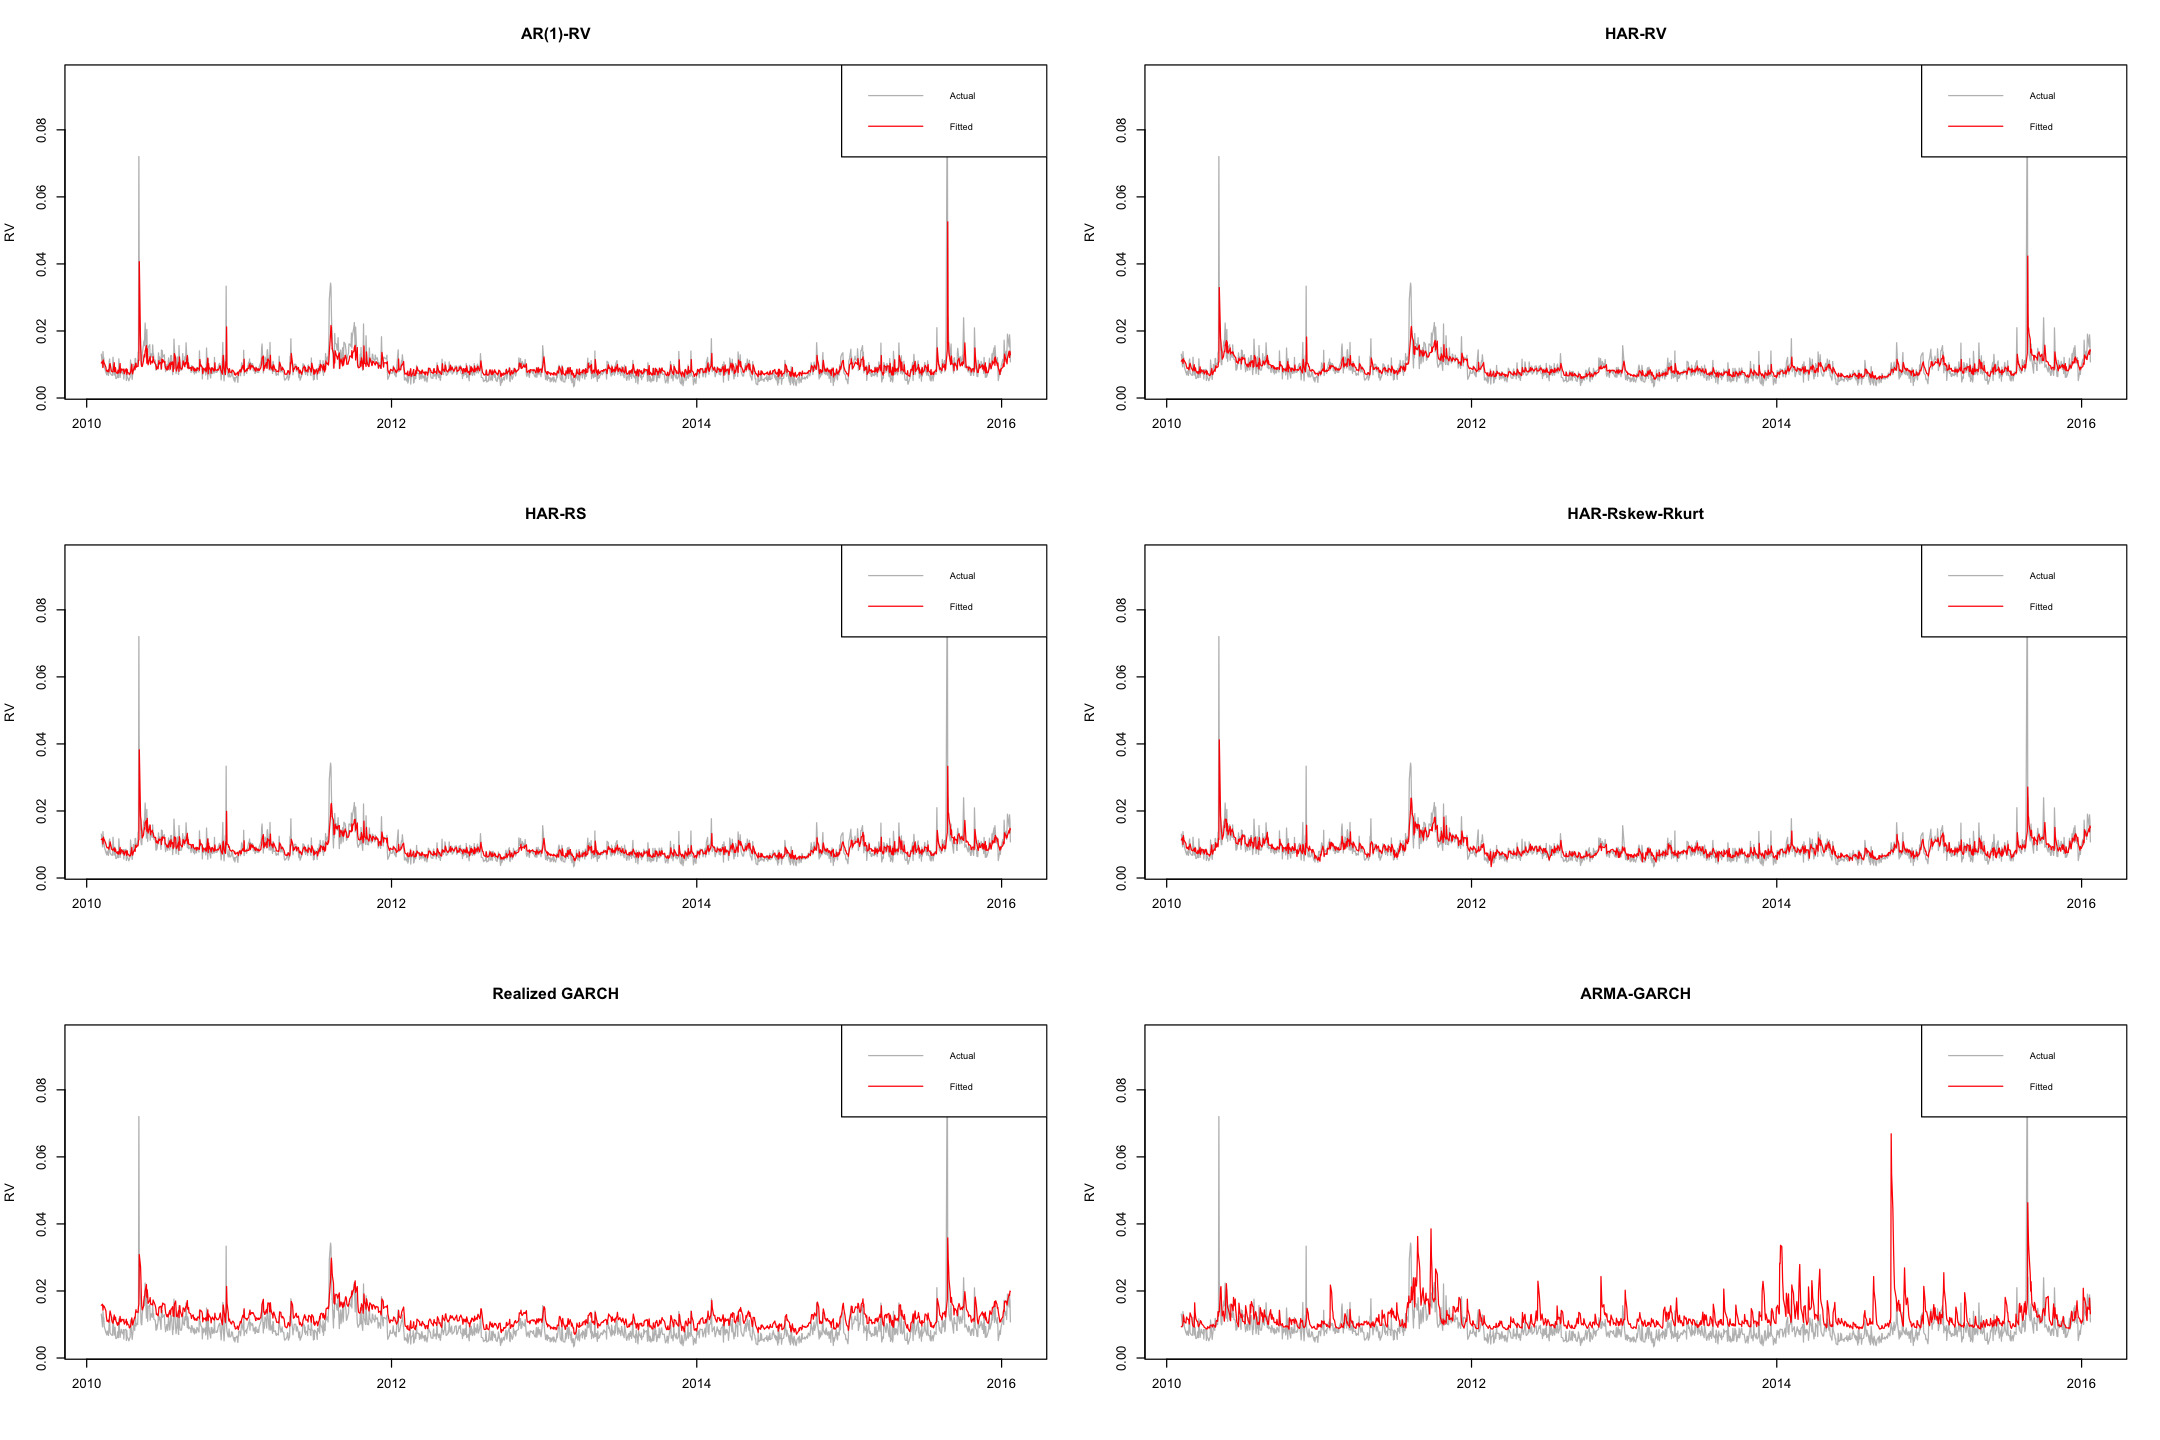

In [65]:
options(repr.plot.height = 12, repr.plot.width = 18)
par(mfrow = c(3, 2))

for (i in seq_along(colnames(fits))) {
  plot(model_df$date, actual, type = "l", col = "grey",
       main = colnames(fits)[i], xlab = "", ylab = "RV")
  lines(model_df$date, fits[, i], col = "red")
  legend("topright", c("Actual", "Fitted"), col = c("grey", "red"), lty = 1, cex = 0.7)
}

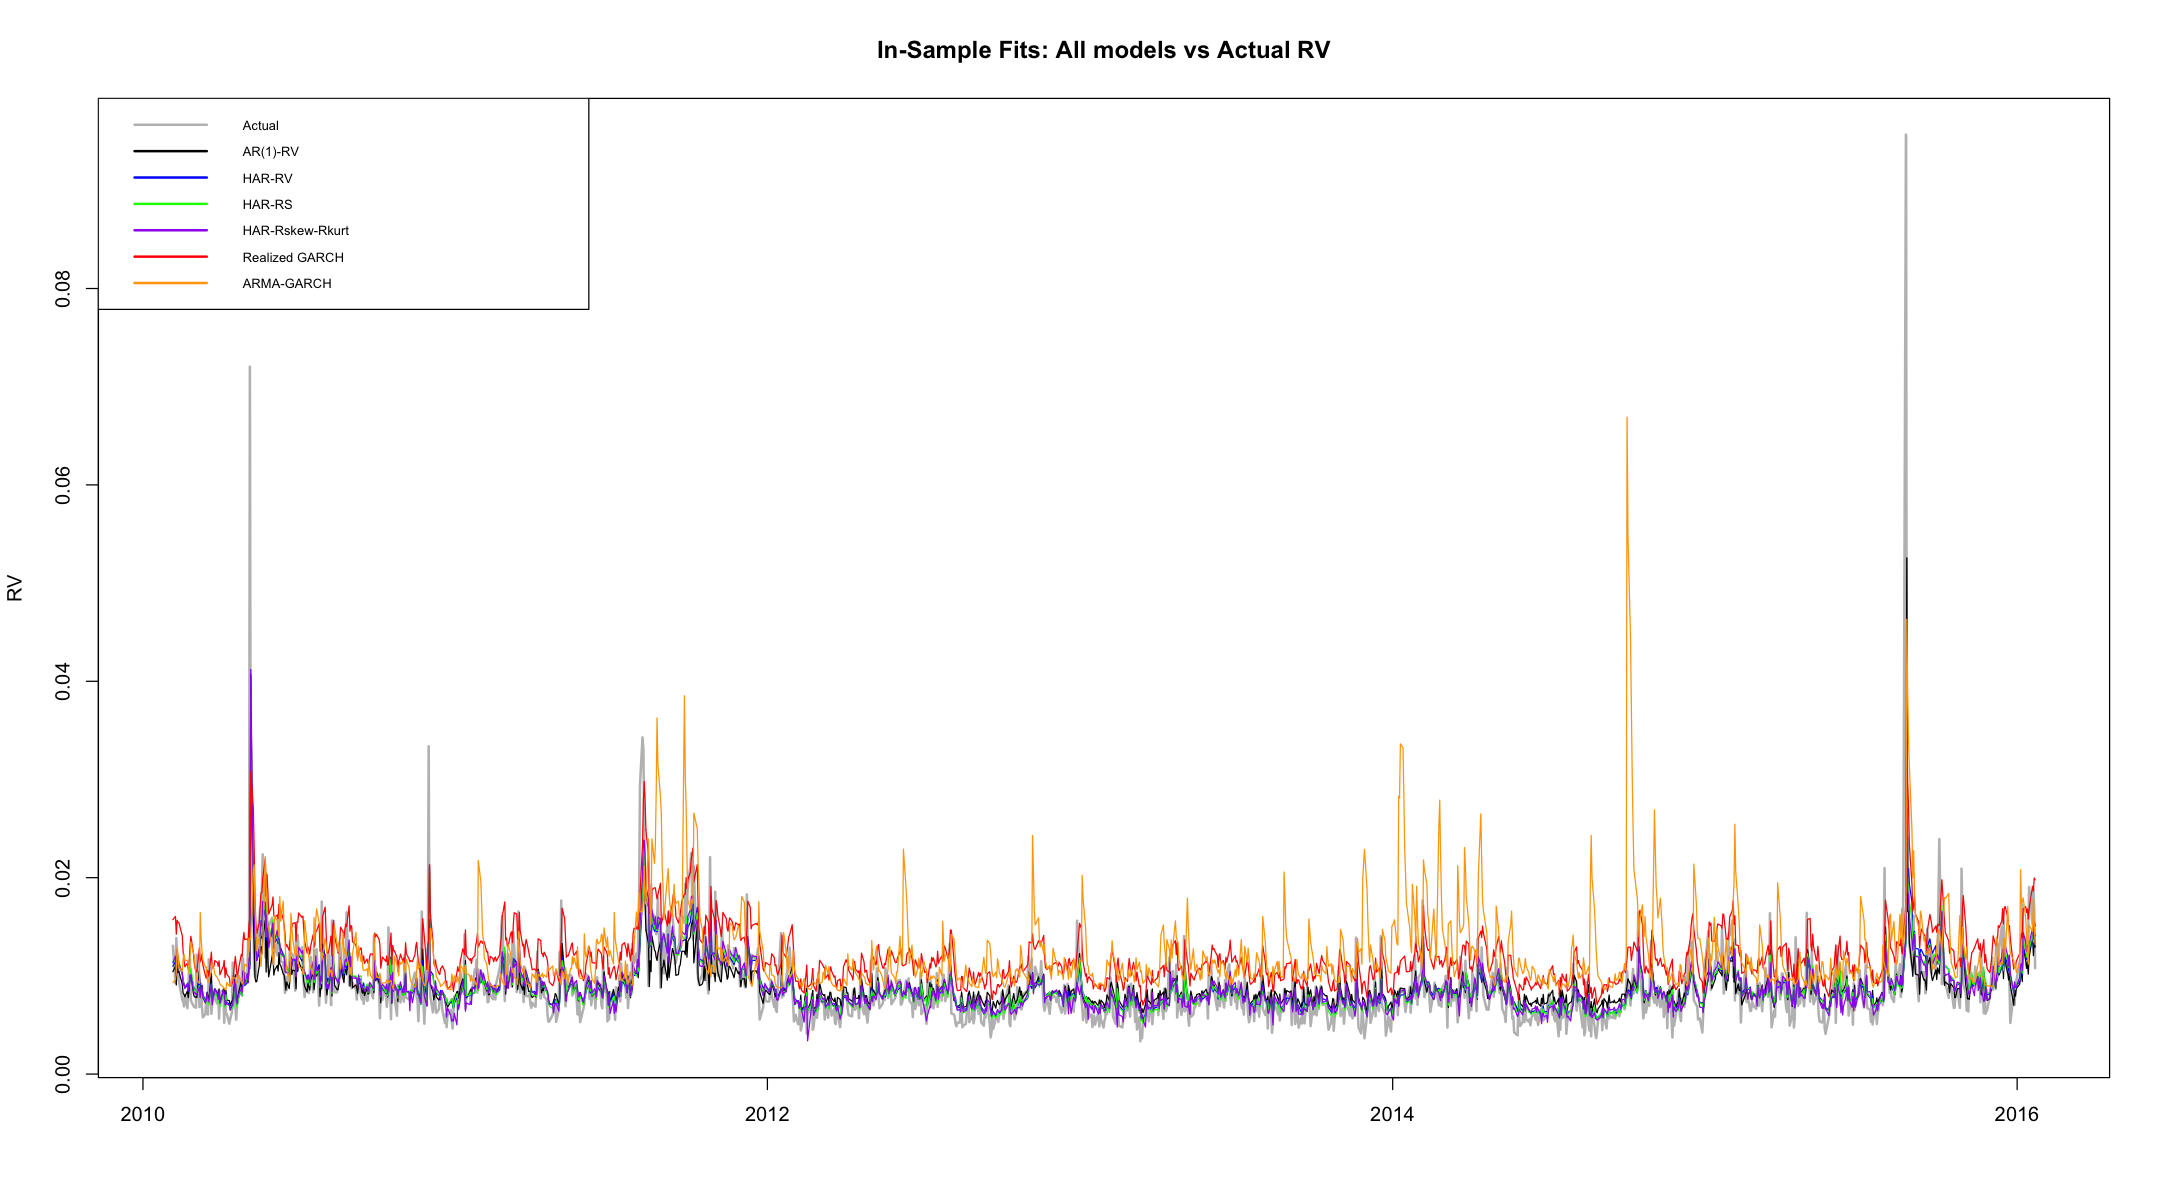

In [64]:
options(repr.plot.height = 10, repr.plot.width = 18)
colors <- c("black", "blue", "green", "purple", "red", "orange")

plot(model_df$date, actual, type="l", col="grey", lwd=2,
    main="In-Sample Fits: All models vs Actual RV",
    xlab="", ylab="RV"
)

for (i in 1:ncol(fits)){
    lines(model_df$date, fits[, i], col=colors[i], lwd=1)
}

legend("topleft", legend=c("Actual", colnames(fits)),
    col=c("grey", colors),
    lwd=c(2), cex=0.65
)

The following patterns can be observed from the plot:

The HAR family models follow closely actual RV during calm periods but consistently undershoot large spikes (smooth out the extreme values). ARMA-GARCH is the most volatile fitted line, which overshoots consistently and significantly, especially in the period 2014-15 (it overreacts to shocks). Furthermore, Realized GARCH and ARMA-GARCH consistently fit values above actual RV.

The HAR models are hardly distinguishable in the plots (confirmed by the similar R^2) and fit actual RV more closely than the GARCH family.

Since GARCH family models update conditional variance only from returns, they are slower to react to volatility changes. The HAR family use lagged RV directly and as such respond more quickly to changes in RV levels.

It appears that HAR models track the general level of RV better, but underestimate large volatility spikes on consistent basis. ARMA-GARCH introduces a lot of noise (false spikes). Overall, none of the models capture the largest spikes in volatility accurately. Realized GARCH appears to be the more balanced GARCH model. HAR_Rskew_Rkurt obtains the lowest MSE and MAE of all models.

# 3. Forecasts

## Setup

In [ ]:
w_l <- 750 #window len
n_for <- nrow(model_df) - w_l #forecast period

forecast_dates <- model_df$date[(w_l + 1):(nrow(model_df))] #vector of dates
actual_oos <- model_df$RV[(w_l + 1):nrow(model_df)]

#n_for
#length(forecast_dates)
#length(actual_oos)

In [106]:
#Expanding window
#HAR family 
m1_exp <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1, data = model_df[1:(w_l + x - 1), ]) 
    predict(fit, newdata = model_df[w_l + x, ])
})

m2_exp <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df[1:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m3_exp <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df[1:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m4_exp <- sapply(1:n_for, function(x){
    fit <- lm(
        RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
        RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, 
        data = model_df[1:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

#GARCH family
m5_exp <- ugarchroll(real_garch_spec,
    data = xts(100 * df$ret, order.by = df$date), #scale for convergence
    n.ahead = 1,
    forecast.length = n_for,
    refit.window = 'recursive',
    window.size = w_l,
    solver = 'hybrid',
    refit.every = 1,
    realizedVol = xts(100 * df$RV, order.by = df$date)
)

m6_exp <- ugarchroll(arma_garch_spec,
    data = xts(df$ret, order.by = df$date),
    n.ahead = 1,
    forecast.length = n_for,
    refit.window = 'recursive',
    window.size = w_l,
    solver = 'hybrid',
    refit.every = 1
)

In [139]:
#Rolling window
#HAR family 
m1_roll <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1, data = model_df[x:(w_l + x - 1), ]) 
    predict(fit, newdata = model_df[w_l + x, ])
})

m2_roll <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df[x:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m3_roll <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df[x:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m4_roll <- sapply(1:n_for, function(x){
    fit <- lm(
        RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
        RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, 
        data = model_df[x:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m6_roll <- ugarchroll(arma_garch_spec,
    data = xts(df$ret, order.by = df$date),
    n.ahead = 1,
    forecast.length = n_for,
    refit.window = 'moving',
    window.size = w_l,
    solver = 'hybrid',
    refit.every = 1
)

Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .rollfdensity.real(spec = spec, data = data, n.ahead = n.ahead, :
"
non-converged estimation windows present...resubsmit object with different solver parameters..."
Warning message in arima(data, order = c(modelinc[2], 0, modelinc[3]), include.mean = modelinc[1], :
"possible convergence problem: optim gave code = 1"
Warning message in arima(data, order = c(modelinc[2], 0, modelinc[3]), include.mean = modelinc[1], :
"possible convergence problem: optim gave code = 1"


In [142]:
# Realized GARCH (manual function) - rugarch does not work (fails to converge)
#Fit all windows and store results
m5_roll_fits <- lapply(1:n_for, function(x) {
    tryCatch(
        ugarchfit(real_garch_spec,
            data = xts(1000 * df$ret, order.by = df$date)[x:(x + w_l - 1)],
            solver = 'hybrid',
            realizedVol = xts(1000 * df$RV, order.by = df$date)[x:(x + w_l - 1)]
        ),
        error = function(e) NULL
    )
})

Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
"
rugarch-->warning: failed to invert hessian
"


[1] 0

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.001188 0.008557 0.010028 0.011001 0.012054 0.181428 

In [148]:
#Forecast Realized GARCH
m5_roll_forecast <- sapply(1:n_for, function(x) {
    if(is.null(m5_roll_fits[[x]])) return(NA)
    as.numeric(ugarchforecast(m5_roll_fits[[x]], n.ahead = 1)@forecast$sigmaFor) / 1000
})

length(m5_roll_forecast)

[1] 728

In [151]:
#Get GARCH forecasts 
m5_exp_forecast <- m5_exp@forecast$density$Sigma / 100 #re-scale back
m6_exp_forecast <- m6_exp@forecast$density$Sigma

#m5_roll_forecast excracted from manual func
m6_roll_forecast <- m6_roll@forecast$density$Sigma

#Put forecasts into matrices
forecasts_exp <- cbind(m1_exp, m2_exp, m3_exp, m4_exp, m5_exp_forecast, m6_exp_forecast)
forecasts_roll <- cbind(m1_roll, m2_roll, m3_roll, m4_roll, m5_roll_forecast, m6_roll_forecast)

colnames(forecasts_exp) <- colnames(forecasts_roll) <- c("AR", "HAR", "HAR-RS", "HAR-RS-RK", "RealGARCH", "ARMA-GARCH")

## Forecast Plots

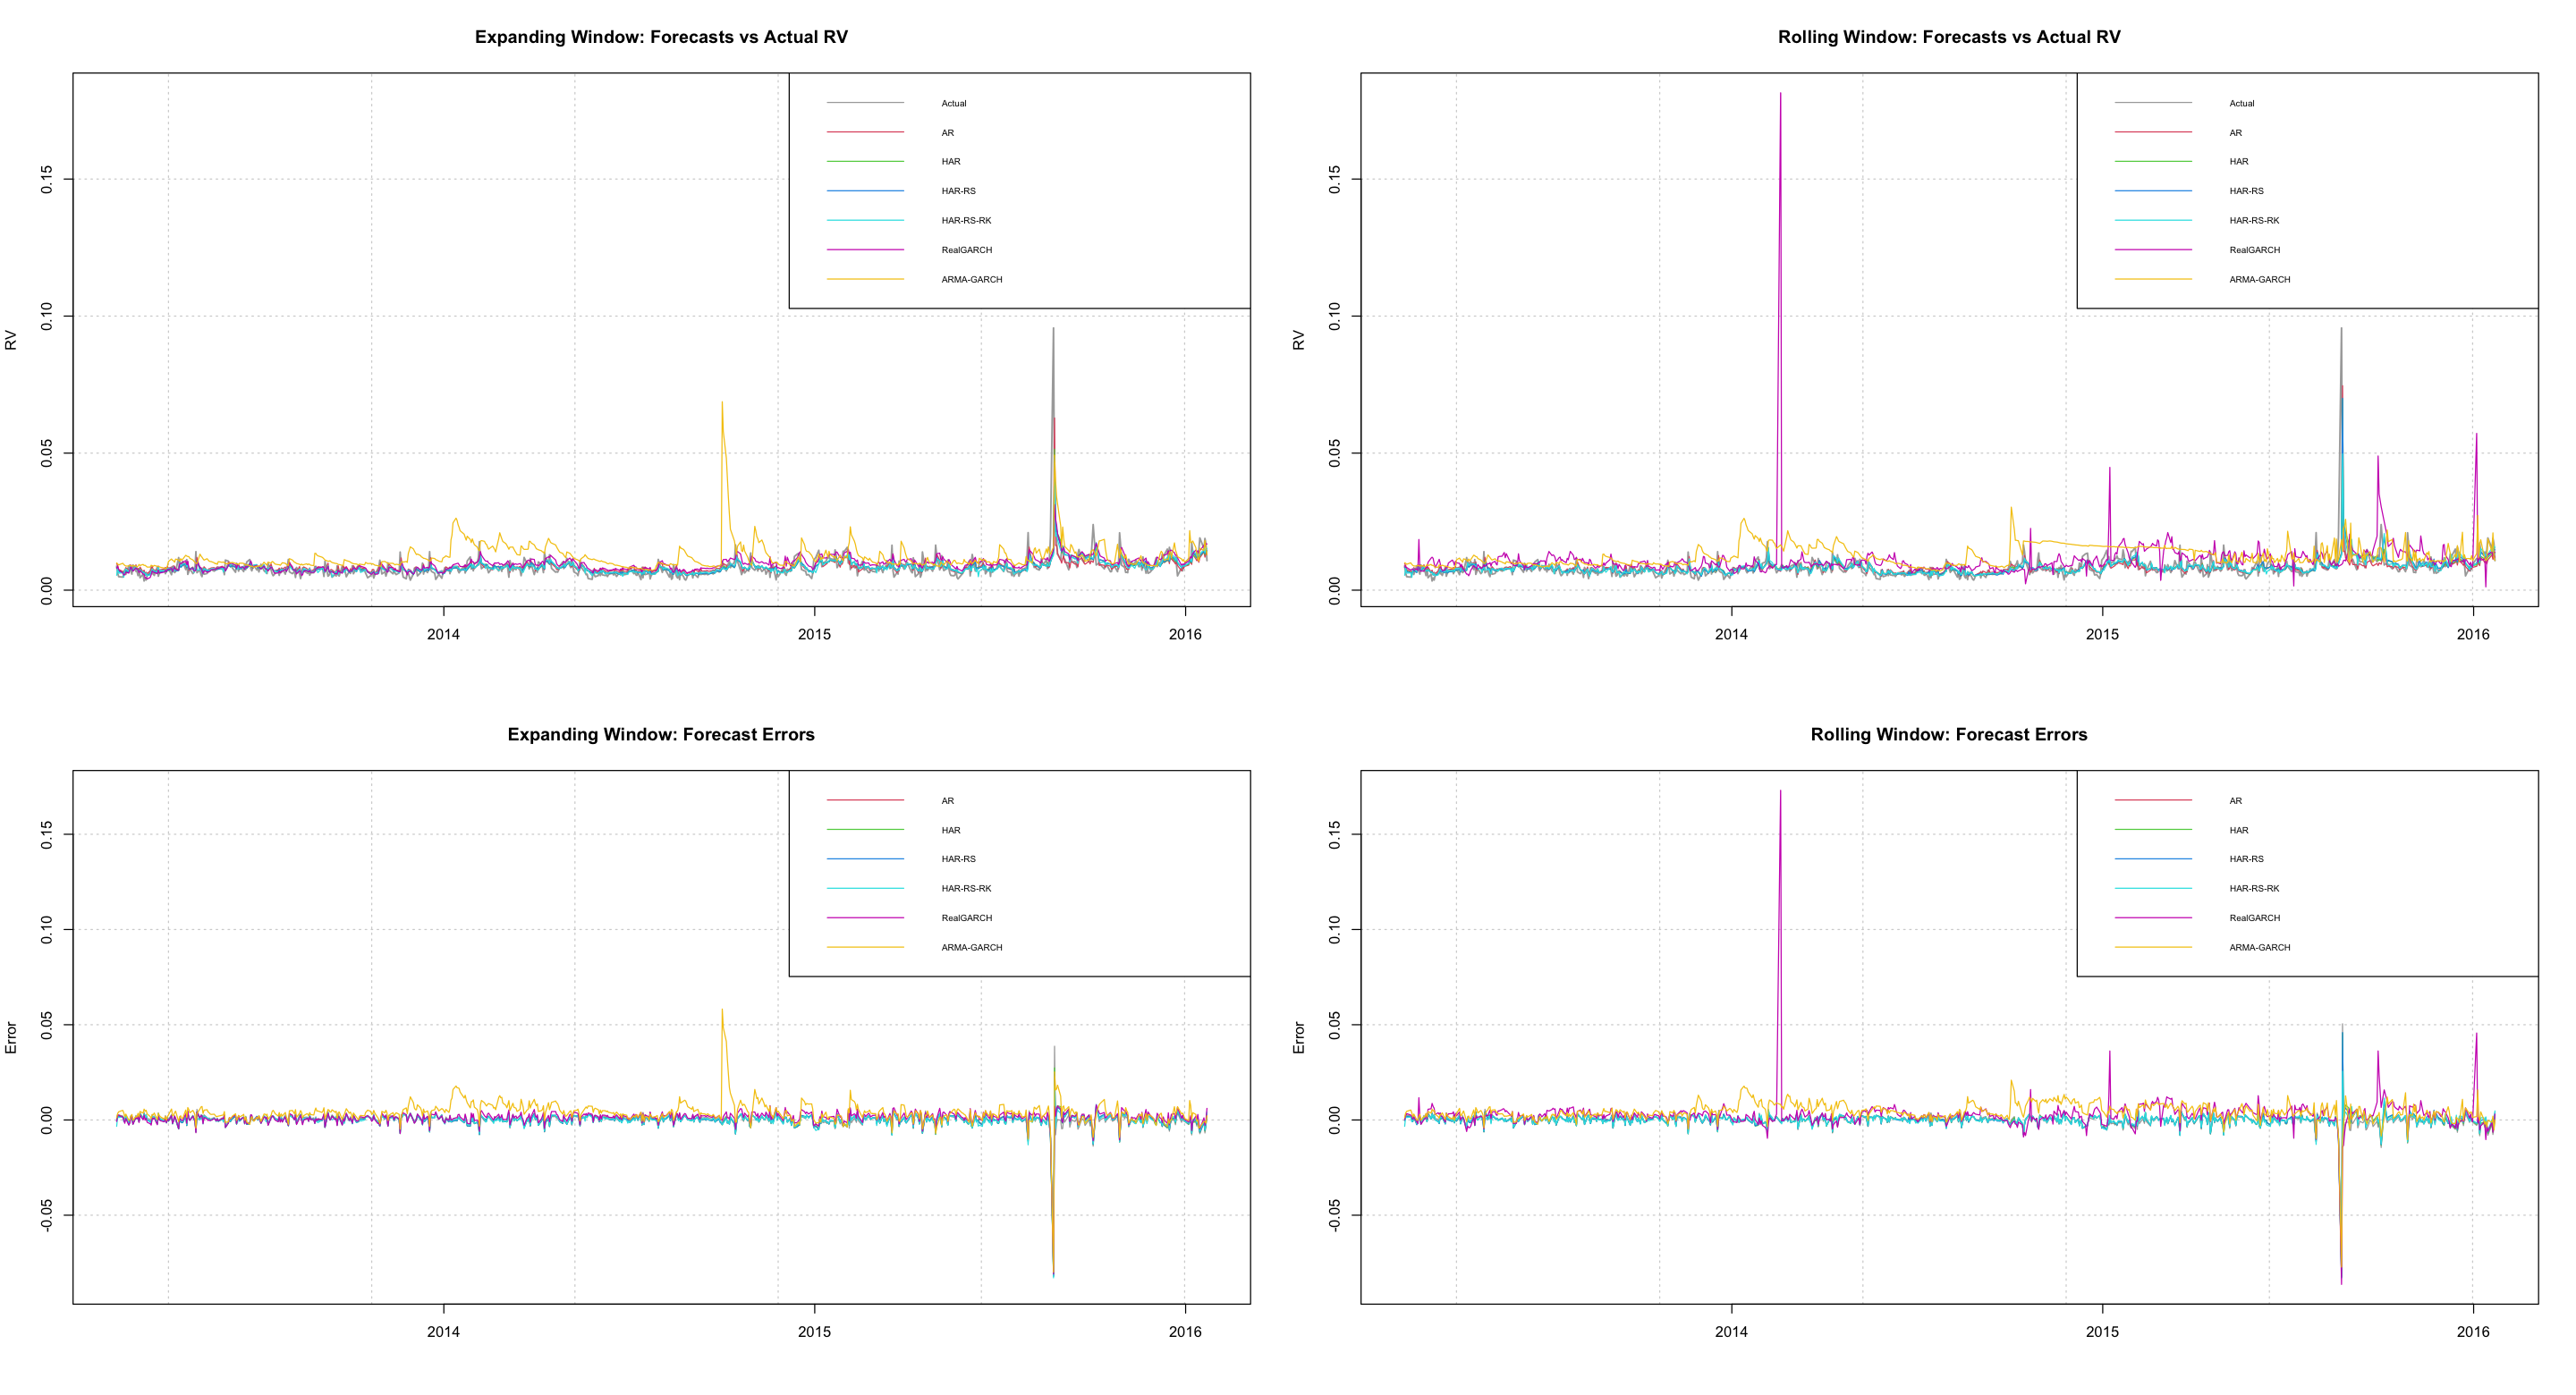

In [178]:
##Actual vs forecast RV
options(repr.plot.height = 13, repr.plot.width = 24)
par(mfrow = c(2, 2))
y_lim <- range(c(actual_oos, forecasts_exp, forecasts_roll))

#Expanding window
plot(forecast_dates, actual_oos, type = "l", col = "darkgrey", lwd = 1.5,
    main = "Expanding Window: Forecasts vs Actual RV",
    xlab = "", ylab = "RV", ylim = y_lim,
    panel.first = grid()
)

for (i in 1:6) lines(forecast_dates, forecasts_exp[, i], col = i + 1, lty = 1)
legend("topright", legend = c("Actual", colnames(forecasts_exp)),
    col = c("darkgrey", 2:7), lty = 1, cex = 0.6
)

#Rolling window
plot(forecast_dates, actual_oos, type = "l", col = "darkgrey", lwd = 1.5,
    main = "Rolling Window: Forecasts vs Actual RV",
    xlab = "", ylab = "RV", ylim = y_lim,
    panel.first = grid()
)

for (i in 1:6) lines(forecast_dates, forecasts_roll[, i], col = i + 1, lty = 1)
legend("topright", legend = c("Actual", colnames(forecasts_roll)),
    col = c("darkgrey", 2:7), lty = 1, cex=0.6, 
)


##Errors plot
errors_exp <- forecasts_exp - actual_oos
errors_roll <- forecasts_roll - actual_oos

#Expanding window
plot(forecast_dates, errors_exp[, 1], type = "l", col = "darkgrey",
    main = "Expanding Window: Forecast Errors",
    xlab = "", ylab = "Error", ylim = range(errors_exp, errors_roll),
    panel.first = grid())
for (i in 2:6) lines(forecast_dates, errors_exp[, i], col = i + 1)
legend("topright", legend = colnames(forecasts_exp), col = 2:7, lty = 1, cex = 0.6)

#Rolling window
plot(forecast_dates, errors_roll[, 1], type = "l", col = "darkgrey",
    main = "Rolling Window: Forecast Errors",
    xlab = "", ylab = "Error", ylim = range(errors_exp, errors_roll),
    panel.first = grid())
for (i in 2:6) lines(forecast_dates, errors_roll[, i], col = i + 1)
legend("topright", legend = colnames(forecasts_roll), col = 2:7, lty = 1, cex = 0.6)

## Loss Functions

In [166]:
#MSE and MAE
mse <- function(actual, forecast) mean((actual - forecast)^2)
mae <- function(actual, forecast) mean(abs(actual - forecast))

#Loss matrices
loss_exp <- apply(forecasts_exp, 2, function(f) c(MSE = mse(actual_oos, f), MAE = mae(actual_oos, f)))
loss_roll <- apply(forecasts_roll, 2, function(f) c(MSE = mse(actual_oos, f), MAE = mae(actual_oos, f)))

loss_table <- data.frame(
    Scheme = rep(c("Expanding", "Rolling"), each = 6),
    Model = rep(colnames(forecasts_exp), 2),
    MSE = c(loss_exp["MSE", ], loss_roll["MSE", ]),
    MAE = c(loss_exp["MAE", ], loss_roll["MAE", ])
) 
loss_table

Scheme,Model,MSE,MAE
<chr>,<chr>,<dbl>,<dbl>
Expanding,AR,1.638522e-05,0.001895814
Expanding,HAR,1.524939e-05,0.001798269
Expanding,HAR-RS,1.498202e-05,0.001782688
Expanding,HAR-RS-RK,1.463733e-05,0.001748864
Expanding,RealGARCH,1.602810e-05,0.002208673
Expanding,ARMA-GARCH,4.918053e-05,0.004534690
Rolling,AR,1.840468e-05,0.001933167
Rolling,HAR,1.726011e-05,0.001827172
Rolling,HAR-RS,1.736058e-05,0.001823691


## Diebold-Mariano test

The Diebold-Mariano test assesses whether the difference in forecast accuracy between two models is statistically significant. For each pair of models, the test compares their loss series under $H_0$ of equal predictive accuracy:

$$DM = \frac{\bar{d}}{\sqrt{\hat{V}(\bar{d}) / T}} \xrightarrow{d} N(0,1)$$

where $\bar{d} = \frac{1}{T}\sum_{t=1}^T d_t$ is the mean loss differential, $d_t = L(\hat{e}_{1,t}) - L(\hat{e}_{2,t})$ is the difference in loss between model 1 and model 2 at time $t$, and $\hat{V}(\bar{d})$ is a HAC estimator of the variance of $\bar{d}$. With MSE, the loss is: $L(\hat{e}_t) = (\hat{RV}_t - RV_t)^2$.

In [180]:
##Loss vectors and p-values
#MSE loss vectors
mse_loss_exp <- apply(forecasts_exp, 2, function(f) (f - actual_oos)^2)
mse_loss_roll <- apply(forecasts_roll, 2, function(f) (f - actual_oos)^2)

pairs <- combn(1:6, 2) #all possible combinations

#Expanding window DM test
dm_pval_exp <- apply(pairs, 2, function(p) #vector of 15 p-vals
    dm.test(mse_loss_exp[, p[1]], mse_loss_exp[, p[2]],
        alternative = "two.sided")$p.value #test both directions
)

#Rolling window
dm_pval_roll <- apply(pairs, 2, function(p)
    dm.test(mse_loss_roll[, p[1]], mse_loss_roll[, p[2]],
        alternative = "two.sided")$p.value
)

In [ ]:
##Organize results into a matrix
#empty matrices
models <- colnames(forecasts_exp)
dm_matrix_exp <- matrix("", 6, 6, dimnames = list(models, models)) #rows = model 1, cols = model 2
dm_matrix_roll <- matrix("", 6, 6, dimnames = list(models, models))

#assign to upper triangle
for (k in 1:ncol(pairs)) {
    dm_matrix_exp[pairs[1, k], pairs[2, k]] <- round(dm_pval_exp[k], 3)
    dm_matrix_roll[pairs[1, k], pairs[2,k]] <- round(dm_pval_roll[k], 3)
}

dm_matrix_exp
dm_matrix_roll

,AR,HAR,HAR-RS,HAR-RS-RK,RealGARCH,ARMA-GARCH
AR,,0.751,0.771,0.616,0.44,0.142
HAR,,,0.983,0.447,0.226,0.179
HAR-RS,,,,0.388,0.261,0.181
HAR-RS-RK,,,,,0.307,0.246
RealGARCH,,,,,,0.108
ARMA-GARCH,,,,,,


,AR,HAR,HAR-RS,HAR-RS-RK,RealGARCH,ARMA-GARCH
AR,,0.567,0.918,0.597,0.311,0.234
HAR,,,0.278,0.614,0.31,0.27
HAR-RS,,,,0.432,0.311,0.269
HAR-RS-RK,,,,,0.309,0.401
RealGARCH,,,,,,0.304
ARMA-GARCH,,,,,,


## Mincer-Zarnowitz Regression

The goal of the MZ Regression is to test whether a forecast fully and correctly uses all available information with no systematic bias (i.e. it is efficient):

$$RV_t = \alpha + \beta \hat{RV}_t + \varepsilon_t$$

Under $H_0$ of forecast efficiency, $\alpha = 0$ and $\beta = 1$ (unbiased and correctly scaled).

Since OLS tests $H_0: \beta = 0$, we manually compute a t-statistic to test $H_0: \beta = 1$:

$$t = \frac{\hat{\beta} - 1}{SE(\hat{\beta})}$$

In [188]:
##MZ regressions
mz_exp <- lapply(1:6, function(i) lm(actual_oos ~ forecasts_exp[, i]))
names(mz_exp) <- colnames(forecasts_exp)

mz_roll <- lapply(1:6, function(i) lm(actual_oos ~ forecasts_roll[, i]))
names(mz_roll) <- colnames(forecasts_roll)

#summary table
mz_table <- function(mz_list){
    do.call(rbind, lapply(names(mz_list), function(m){
        coef <- summary(mz_list[[m]])$coefficients
        data.frame(
            Model = m,
            Alpha = round(coef[1, "Estimate"], 4),
            Beta = round(coef[2, "Estimate"], 4),
            R2 = round(summary(mz_list[[m]])$r.squared, 4),
            t_beta1 = round((coef[2, "Estimate"] - 1) / coef[2, "Std. Error"], 3) #we want to test against 1, not 0
        )
    }))
}

mz_table(mz_exp)
mz_table(mz_roll)

Model,Alpha,Beta,R2,t_beta1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AR,0.0024,0.6920,0.1660,-5.350
HAR,0.0017,0.7883,0.2065,-3.691
HAR-RS,0.0014,0.8238,0.2157,-3.023
HAR-RS-RK,0.0009,0.8904,0.2275,-1.801
RealGARCH,0.0005,0.8287,0.2287,-3.033
ARMA-GARCH,0.0060,0.1911,0.0492,-25.931


Model,Alpha,Beta,R2,t_beta1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AR,0.0040,0.5295,0.1254,-9.066
HAR,0.0035,0.5898,0.1658,-8.353
HAR-RS,0.0035,0.5788,0.1695,-8.857
HAR-RS-RK,0.0022,0.7450,0.2119,-4.782
RealGARCH,0.0079,0.0420,0.0053,-44.644
ARMA-GARCH,0.0046,0.2987,0.0612,-16.154


# Summary